In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score


In [8]:
df1 = pd.read_csv("../HW3/LA_AQS_2023.csv")
df1.head()

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
0,6,37,1103,68103,1,34.06659,-118.22688,WGS84,Ambient Min Temperature,24 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
1,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
2,6,37,1103,62201,1,34.06659,-118.22688,WGS84,Relative Humidity,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
3,6,37,1103,62101,1,34.06659,-118.22688,WGS84,Outdoor Temperature,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
4,6,37,1103,42603,1,34.06659,-118.22688,WGS84,Oxides of nitrogen (NOx),1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


In [9]:
o3 = df1.loc[(df["Parameter Name"] == "Ozone") & (df1["Duration Description"] == "1 HOUR"), ["Date (Local)", "Arithmetic Mean"]].rename(columns={"Arithmetic Mean": "O3_ppb"})
o3["O3_ppb"] = o3["O3_ppb"] * 1000

no2 = df1.loc[(df["Parameter Name"] == "Nitrogen dioxide (NO2)") & (df1["Pollutant Standard"] == "NO2 1-hour 2010"), ["Date (Local)", "Arithmetic Mean"]]
no2 = no2.groupby("Date (Local)", as_index=False)["Arithmetic Mean"].mean().rename(columns={"Arithmetic Mean": "NO2_ppb"})

paired = o3.merge(no2, on="Date (Local)", validate="one_to_one").dropna()

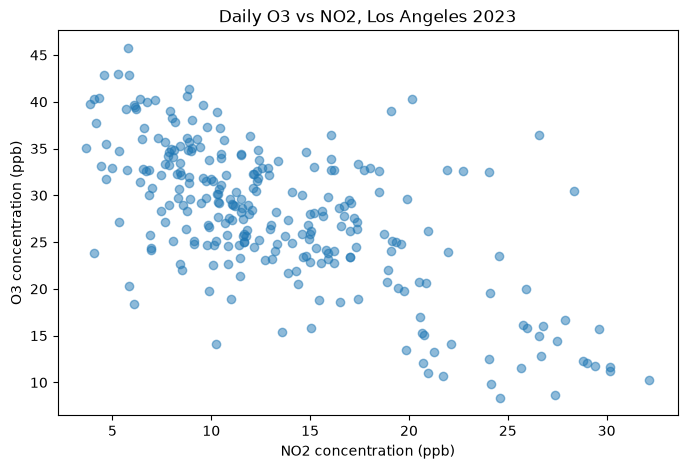

In [23]:
plt.figure(figsize=(8, 5))
plt.scatter(paired["NO2_ppb"], paired["O3_ppb"], alpha=0.5)
plt.xlabel("NO2 concentration (ppb)")
plt.ylabel("O3 concentration (ppb)")
plt.title("Daily O3 vs NO2, Los Angeles 2023")
plt.show()

In [11]:
X = paired[["NO2_ppb"]]
y = paired["O3_ppb"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
o3_model = LinearRegression()
o3_model.fit(X_train, y_train)
o3_pred = o3_model.predict(X_test)
x_line = np.linspace(paired["NO2_ppb"].min(), paired["NO2_ppb"].max(), 100)
line_input = pd.DataFrame({"NO2_ppb": x_line})

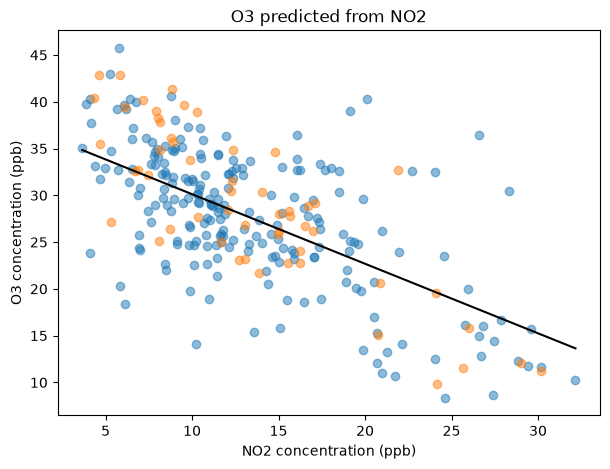

In [24]:
plt.figure(figsize=(7, 5))
plt.scatter(X_train["NO2_ppb"], y_train, label="Training data", alpha=0.5)
plt.scatter(X_test["NO2_ppb"], y_test, label="Test data", alpha=0.5)
plt.plot(x_line, o3_model.predict(line_input), color="black", label="OLS line")
plt.xlabel("NO2 concentration (ppb)")
plt.ylabel("O3 concentration (ppb)")
plt.title("O3 predicted from NO2")

plt.show()

In [17]:
epa_mae = mean_absolute_error(y_test, o3_pred)
epa_r2 = r2_score(y_test, o3_pred)
print(epa_mae)
print(epa_r2)

4.384564064099426
0.5887314082053583


The mean absolute error is 4.38 ppb, as the error.

The line sees the downward trends with R^2 value 0.589, but the spread tell us it is not exacly linear relation between O3 and NO2. 

In [18]:
df2 = pd.read_csv("ManuaLoa_CO2.csv")

co2_train = df2[df2["decimal date"] < 2000]
co2_test = df2[df2["decimal date"] >= 2000]

In [19]:
co2_model = LinearRegression()
co2_model.fit(co2_train[["decimal date"]], co2_train["average"])
co2_pred = co2_model.predict(co2_test[["decimal date"]])
years = np.linspace(df2["decimal date"].min(), df2["decimal date"].max(), 300)
year_input = pd.DataFrame({"decimal date": years})

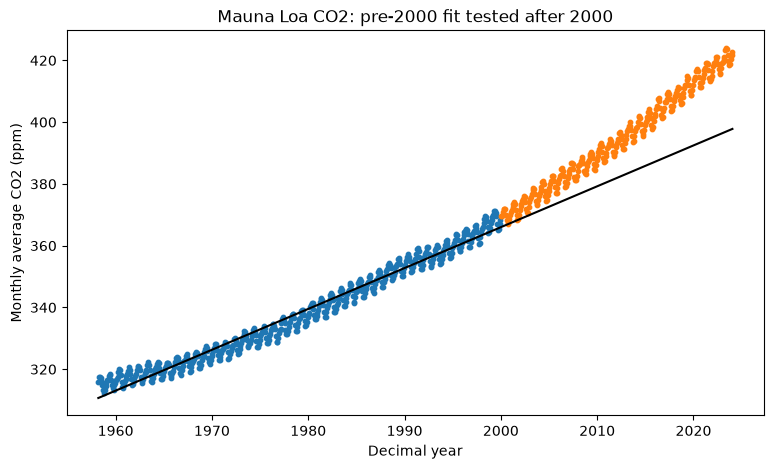

In [20]:
plt.figure(figsize=(9, 5))
plt.scatter(co2_train["decimal date"], co2_train["average"], s=10, label="Before 2000: training")
plt.scatter(co2_test["decimal date"], co2_test["average"], s=10, label="2000 onward: test")
plt.plot(years, co2_model.predict(year_input), color="black", label="Pre-2000 OLS line")
plt.xlabel("Decimal year")
plt.ylabel("Monthly average CO2 (ppm)")
plt.title("Mauna Loa CO2: pre-2000 fit tested after 2000")

plt.show()

In [21]:
co2_mae = mean_absolute_error(co2_test["average"], co2_pred)
co2_r2 = r2_score(co2_test["average"], co2_pred)
print(co2_mae)
print(co2_r2)

12.42973670567126
0.19001653191038226


The predicted line did worse as year increases. After 2000 the diff between true value is gradually increasing. 

No. It was doing well on earlier years, but after 2000 the C02 increase faster then usual. 